# **Upload the SQLite Database to Colab**


In [1]:
from google.colab import files

# Upload the Chinook SQLite database file
uploaded = files.upload()

Saving Chinook_Sqlite.sqlite to Chinook_Sqlite.sqlite


# **Connect to the Database**

In [2]:
import sqlite3
import pandas as pd

# Connect to SQLite database
conn = sqlite3.connect("Chinook_Sqlite.sqlite")

# Preview tables
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
tables

,name
0,Album
1,Artist
2,Customer
3,Employee
4,Genre
5,Invoice
6,InvoiceLine
7,MediaType
8,Playlist
9,PlaylistTrack


# **Top-Selling Products**

In [3]:
query_top_products = """
SELECT
    t.Name AS Product,
    SUM(il.Quantity) AS Total_Quantity_Sold,
    SUM(il.UnitPrice * il.Quantity) AS Total_Revenue
FROM InvoiceLine il
JOIN Track t ON il.TrackId = t.TrackId
GROUP BY t.Name
ORDER BY Total_Quantity_Sold DESC
LIMIT 10;
"""

top_products = pd.read_sql(query_top_products, conn)
top_products

,Product,Total_Quantity_Sold,Total_Revenue
0,The Trooper,5,4.95
1,Untitled,4,3.96
2,The Number Of The Beast,4,3.96
3,Sure Know Something,4,3.96
4,Hallowed Be Thy Name,4,3.96
5,Eruption,4,3.96
6,Where Eagles Dare,3,2.97
7,Welcome Home (Sanitarium),3,2.97
8,Sweetest Thing,3,2.97
9,Surrender,3,2.97


# **Revenue Per Region (Country)**

In [4]:
query_revenue_region = """
SELECT
    c.Country,
    SUM(i.Total) AS Total_Revenue
FROM Invoice i
JOIN Customer c ON i.CustomerId = c.CustomerId
GROUP BY c.Country
ORDER BY Total_Revenue DESC;
"""

revenue_region = pd.read_sql(query_revenue_region, conn)
revenue_region

,Country,Total_Revenue
0,USA,523.06
1,Canada,303.96
2,France,195.10
3,Brazil,190.10
4,Germany,156.48
5,United Kingdom,112.86
6,Czech Republic,90.24
7,Portugal,77.24
8,India,75.26
9,Chile,46.62


# **Monthly Sales Performance**

In [5]:
query_monthly_sales = """
SELECT
    strftime('%Y-%m', InvoiceDate) AS Month,
    SUM(Total) AS Monthly_Revenue
FROM Invoice
GROUP BY Month
ORDER BY Month;
"""

monthly_sales = pd.read_sql(query_monthly_sales, conn)
monthly_sales

,Month,Monthly_Revenue
0,2021-01,35.64
1,2021-02,37.62
2,2021-03,37.62
3,2021-04,37.62
4,2021-05,37.62
5,2021-06,37.62
6,2021-07,37.62
7,2021-08,37.62
8,2021-09,37.62
9,2021-10,37.62


# **Join Example: Product + Album + Artist**

In [6]:
query_product_album_artist = """
SELECT
    t.Name AS Product,
    a.Title AS Album,
    ar.Name AS Artist
FROM Track t
JOIN Album a ON t.AlbumId = a.AlbumId
JOIN Artist ar ON a.ArtistId = ar.ArtistId
LIMIT 10;
"""

product_album_artist = pd.read_sql(query_product_album_artist, conn)
product_album_artist

,Product,Album,Artist
0,For Those About To Rock (We Salute You),For Those About To Rock We Salute You,AC/DC
1,Balls to the Wall,Balls to the Wall,Accept
2,Fast As a Shark,Restless and Wild,Accept
3,Restless and Wild,Restless and Wild,Accept
4,Princess of the Dawn,Restless and Wild,Accept
5,Put The Finger On You,For Those About To Rock We Salute You,AC/DC
6,Let's Get It Up,For Those About To Rock We Salute You,AC/DC
7,Inject The Venom,For Those About To Rock We Salute You,AC/DC
8,Snowballed,For Those About To Rock We Salute You,AC/DC
9,Evil Walks,For Those About To Rock We Salute You,AC/DC


# **Top 3 Products per Genre**

In [8]:
query_top3_genre_fixed = """
SELECT *
FROM (
    SELECT
        t.GenreId,
        t.Name AS Product,
        SUM(il.Quantity) AS Total_Quantity,
        RANK() OVER(PARTITION BY t.GenreId ORDER BY SUM(il.Quantity) DESC) AS RankInGenre
    FROM InvoiceLine il
    JOIN Track t ON il.TrackId = t.TrackId
    GROUP BY t.GenreId, t.Name
) sub
WHERE RankInGenre <= 3
ORDER BY GenreId, RankInGenre;
"""

top3_genre_fixed = pd.read_sql(query_top3_genre_fixed, conn)
top3_genre_fixed

,GenreId,Product,Total_Quantity,RankInGenre
0,1,Sure Know Something,4,1
1,1,Eruption,4,1
2,1,The Number Of The Beast,3,3
3,1,Sweetest Thing,3,3
4,1,Stairway To Heaven,3,3
...,...,...,...,...
272,24,"Symphonie Fantastique, Op. 14: V. Songe d'une ...",2,1
273,24,"Suite No. 3 in D, BWV 1068: III. Gavotte I & II",2,1
274,24,"String Quartet No. 12 in C Minor, D. 703 ""Quar...",2,1
275,24,"Scheherazade, Op. 35: I. The Sea and Sindbad's...",2,1


# **Top 3 Products per Genre with Names**

In [10]:
query_top3_genre_named = """
SELECT sub.GenreName, sub.Product, sub.Total_Quantity, sub.RankInGenre
FROM (
    SELECT
        g.Name AS GenreName,
        t.Name AS Product,
        SUM(il.Quantity) AS Total_Quantity,
        RANK() OVER(PARTITION BY t.GenreId ORDER BY SUM(il.Quantity) DESC) AS RankInGenre
    FROM InvoiceLine il
    JOIN Track t ON il.TrackId = t.TrackId
    JOIN Genre g ON t.GenreId = g.GenreId
    GROUP BY g.Name, t.Name
) sub
WHERE RankInGenre <= 3
ORDER BY GenreName, RankInGenre;
"""

top3_genre_named = pd.read_sql(query_top3_genre_named, conn)
top3_genre_named

,GenreName,Product,Total_Quantity,RankInGenre
0,Alternative,Until We Fall,1,1
1,Alternative,Sound of a Gun,1,1
2,Alternative,Slowness,1,1
3,Alternative,Show Me How to Live (Live at the Quart Festival),1,1
4,Alternative,Shape of Things to Come,1,1
...,...,...,...,...
272,World,Din Din Wo (Little Child),1,1
273,World,Demorou!,1,1
274,World,Cafezinho,1,1
275,World,Aos Leões,1,1


# **Top Selling Tracks Across All Genres**

/tmp/ipython-input-335/3594036834.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


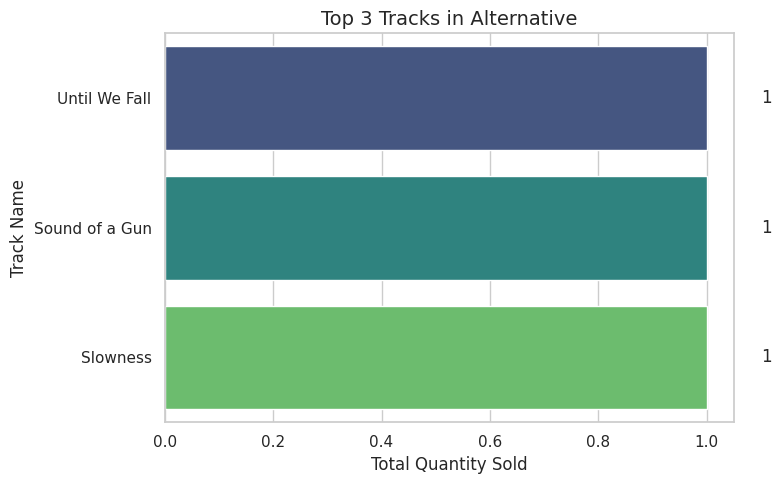

/tmp/ipython-input-335/3594036834.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


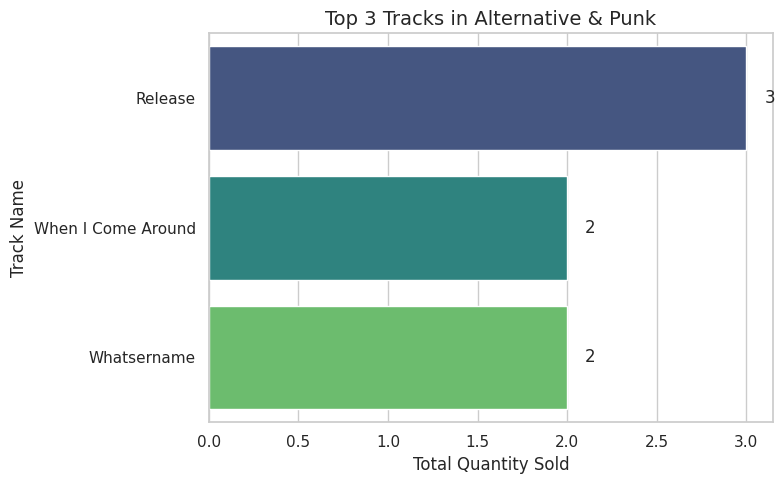

/tmp/ipython-input-335/3594036834.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


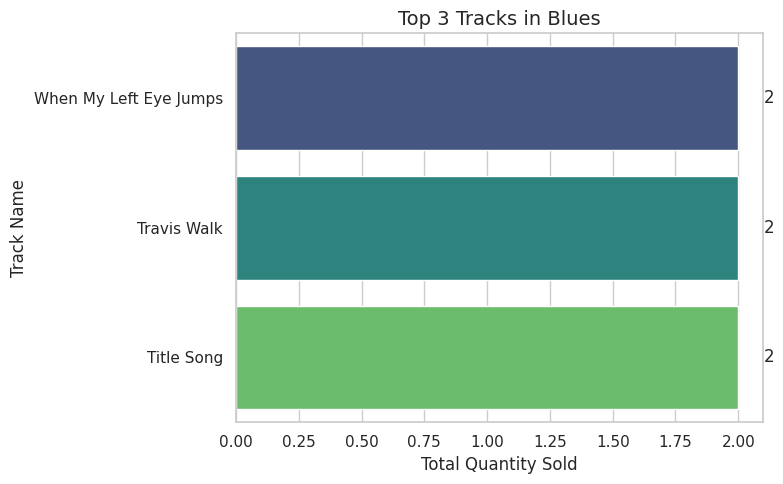

/tmp/ipython-input-335/3594036834.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


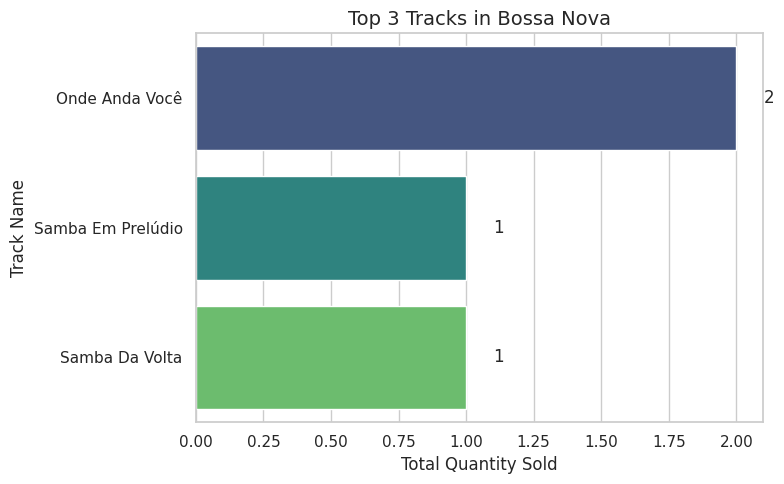

/tmp/ipython-input-335/3594036834.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


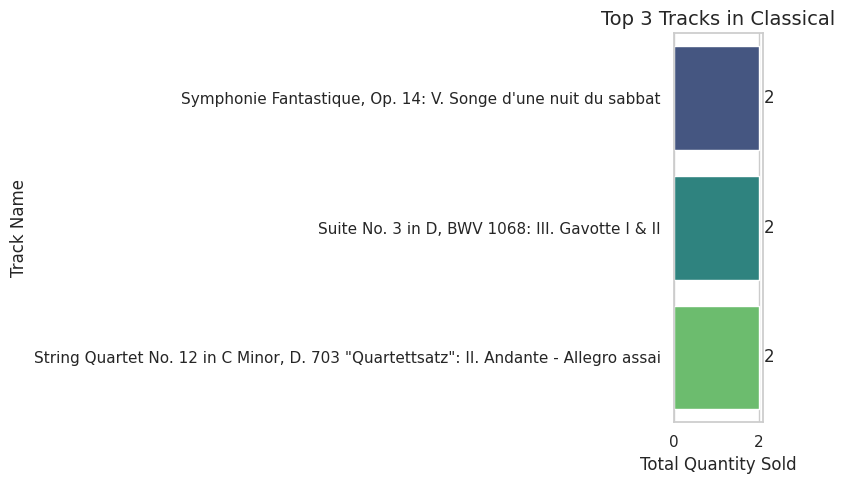

/tmp/ipython-input-335/3594036834.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


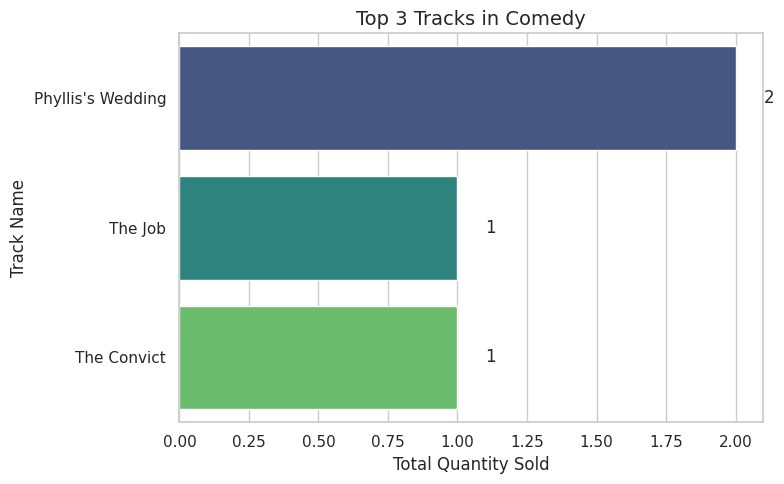

/tmp/ipython-input-335/3594036834.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


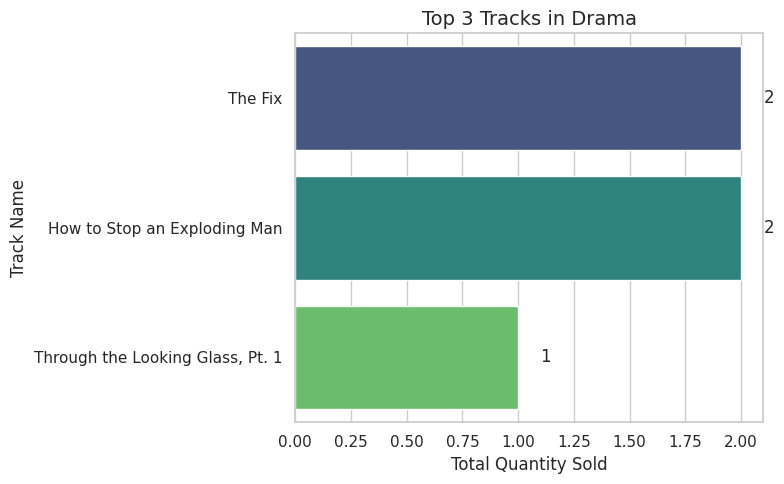

/tmp/ipython-input-335/3594036834.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


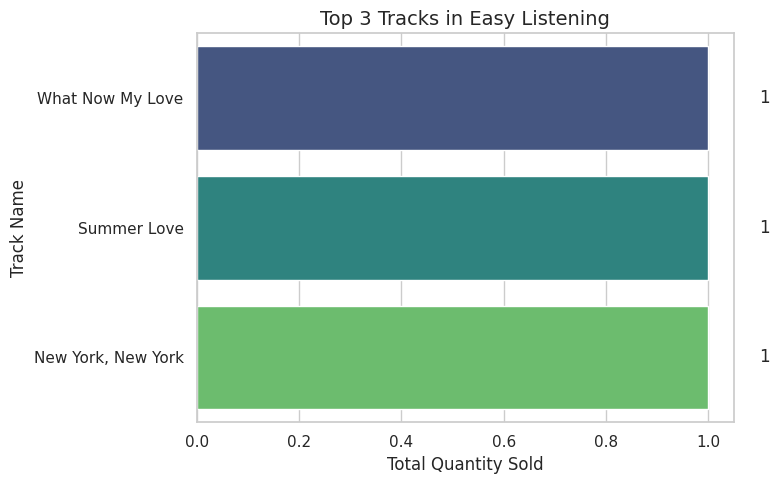

/tmp/ipython-input-335/3594036834.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


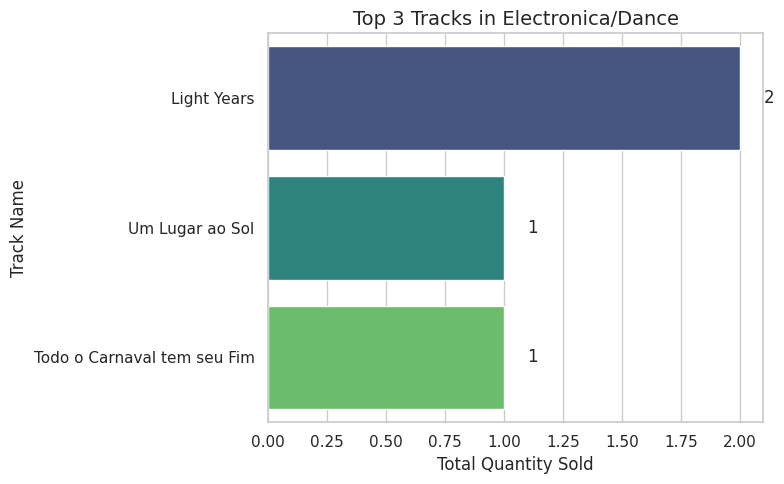

/tmp/ipython-input-335/3594036834.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


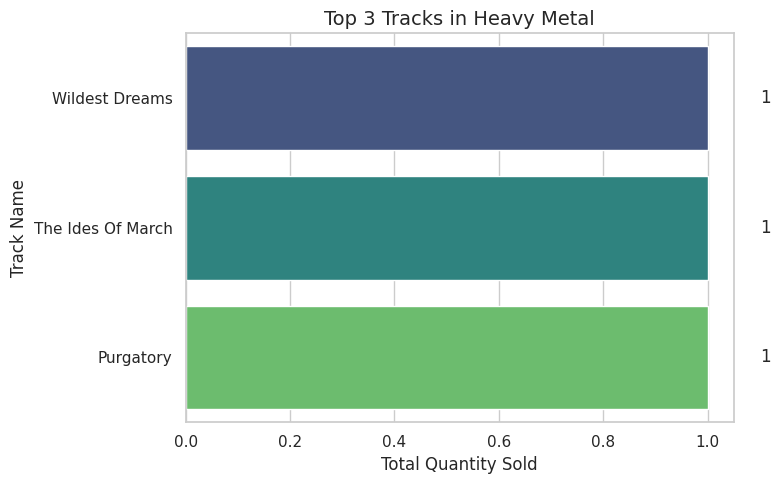

/tmp/ipython-input-335/3594036834.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


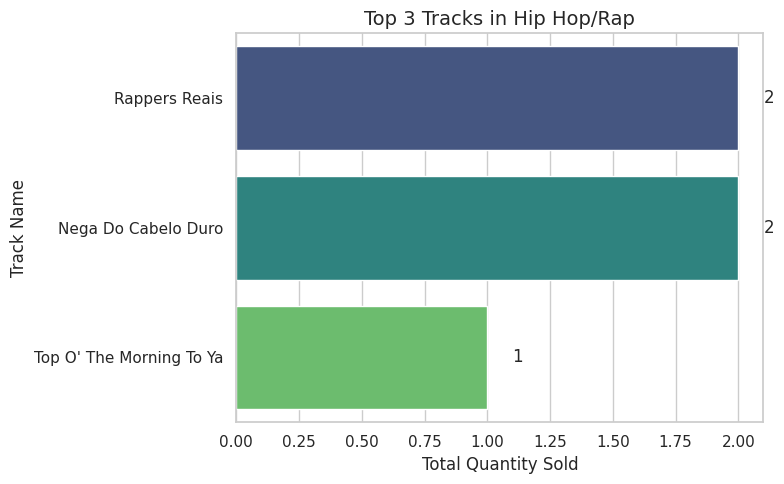

/tmp/ipython-input-335/3594036834.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


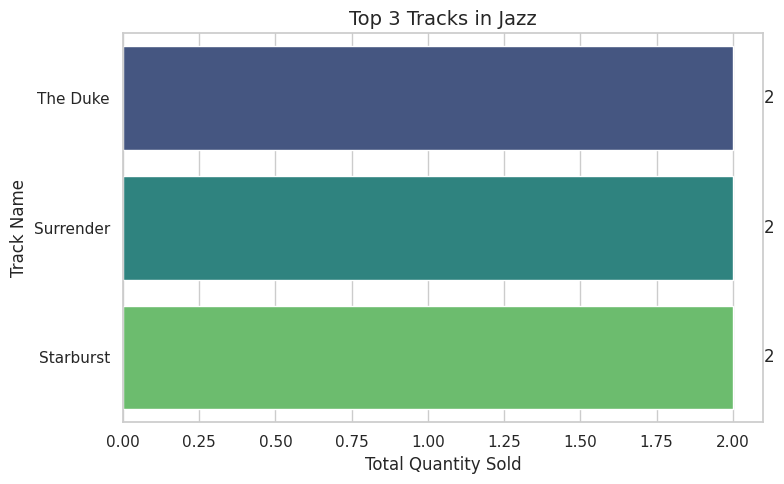

/tmp/ipython-input-335/3594036834.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


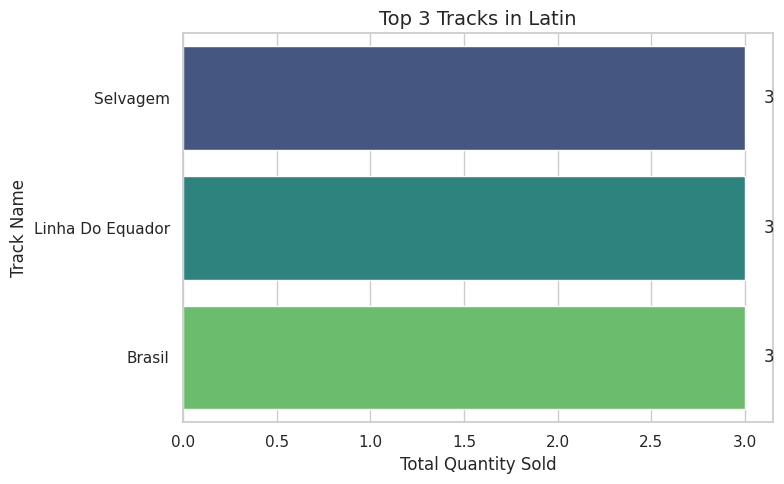

/tmp/ipython-input-335/3594036834.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


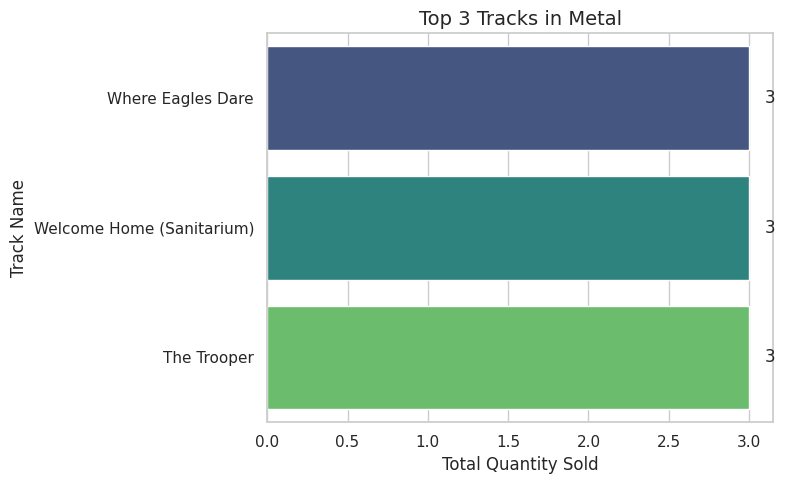

/tmp/ipython-input-335/3594036834.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


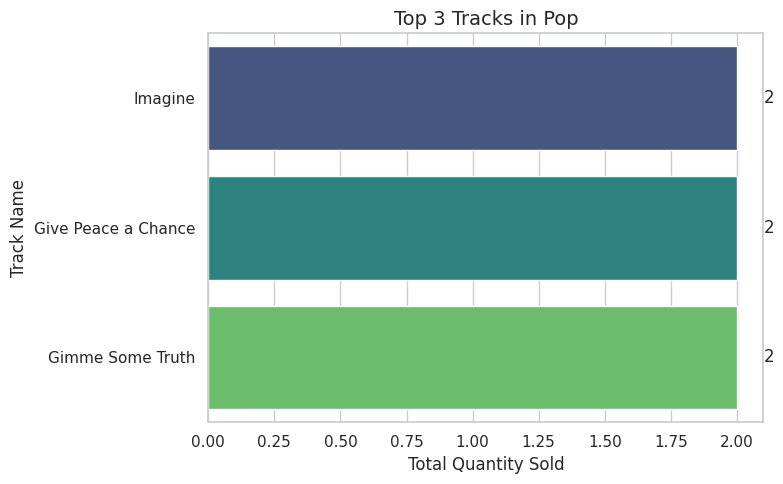

/tmp/ipython-input-335/3594036834.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


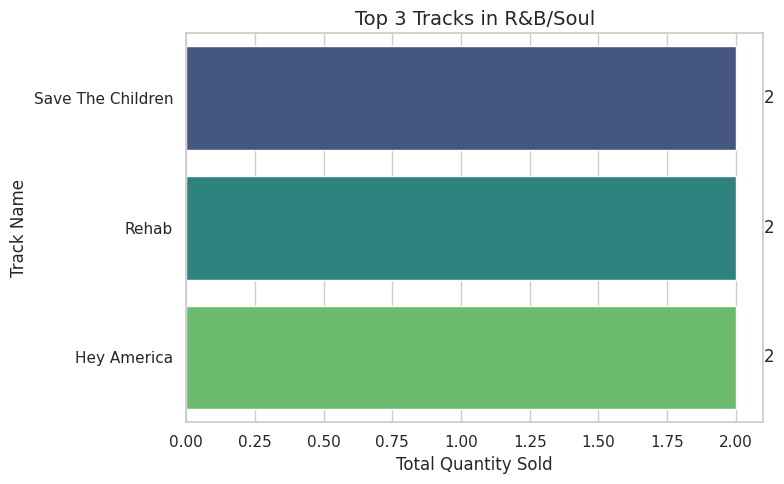

/tmp/ipython-input-335/3594036834.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


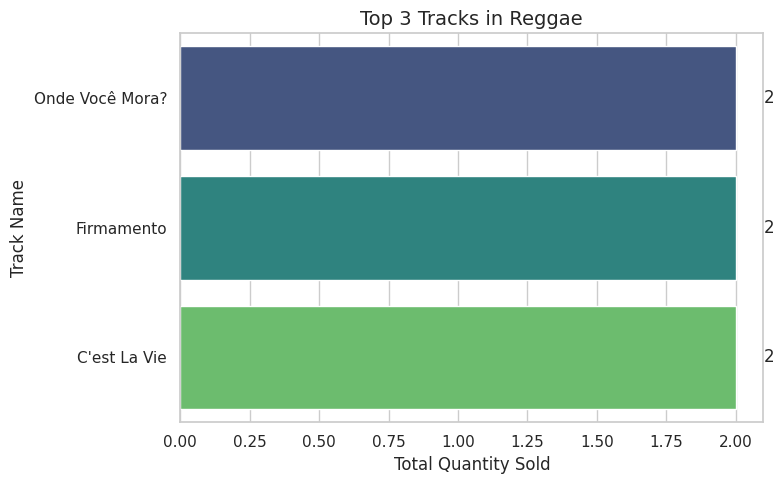

/tmp/ipython-input-335/3594036834.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


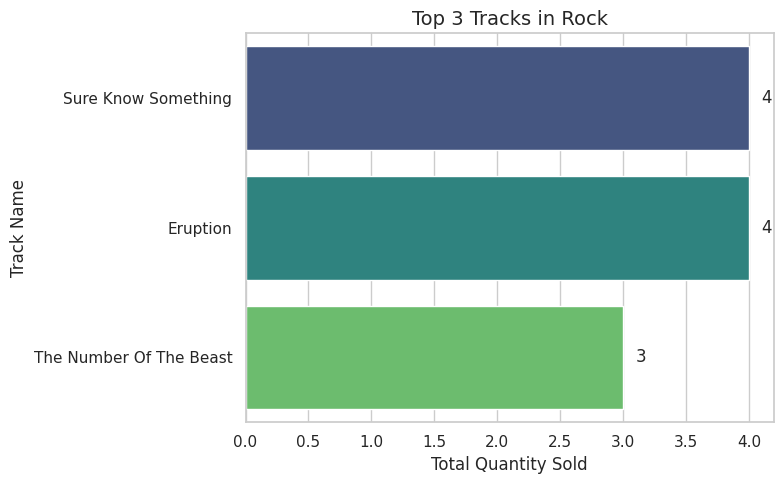

/tmp/ipython-input-335/3594036834.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


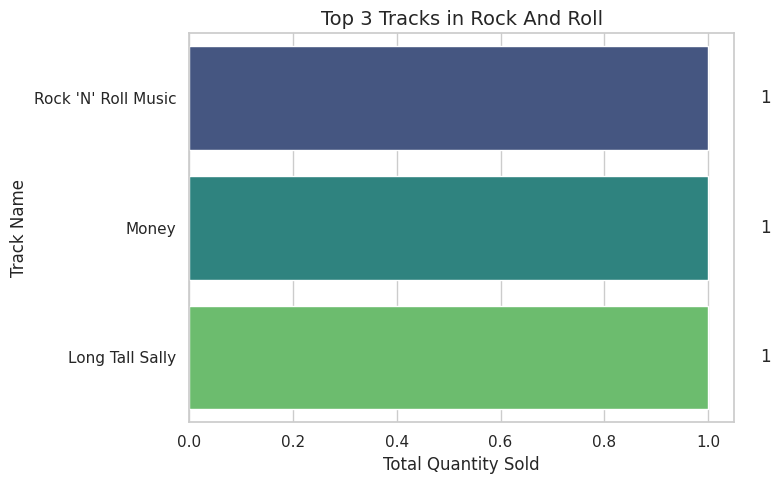

/tmp/ipython-input-335/3594036834.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


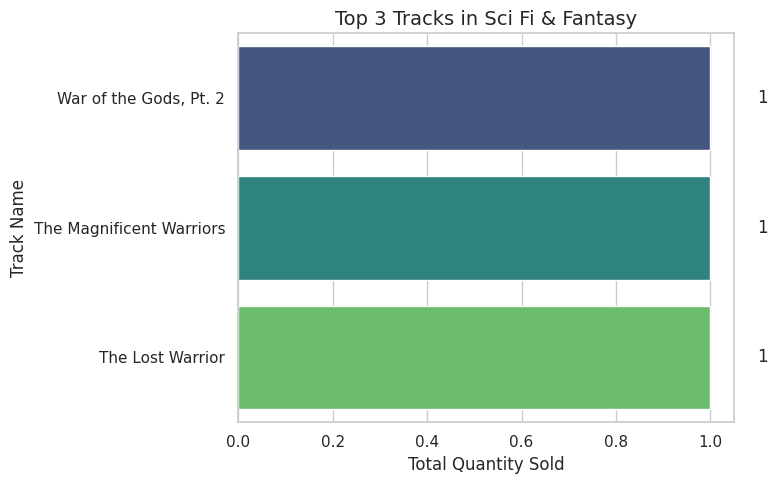

/tmp/ipython-input-335/3594036834.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


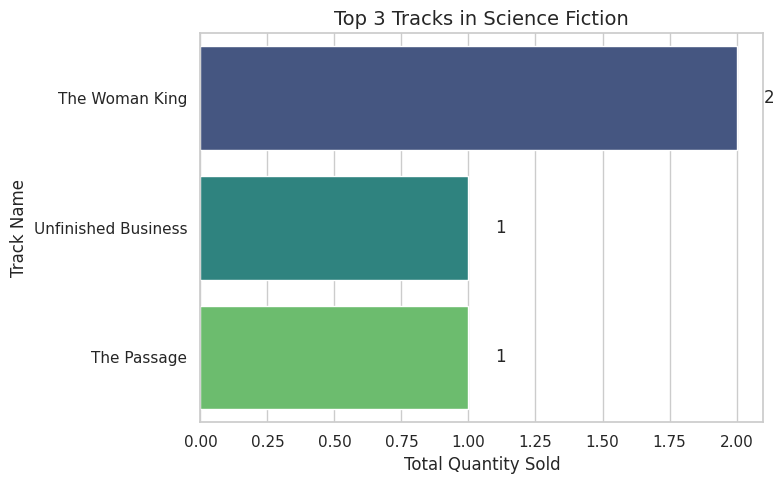

/tmp/ipython-input-335/3594036834.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


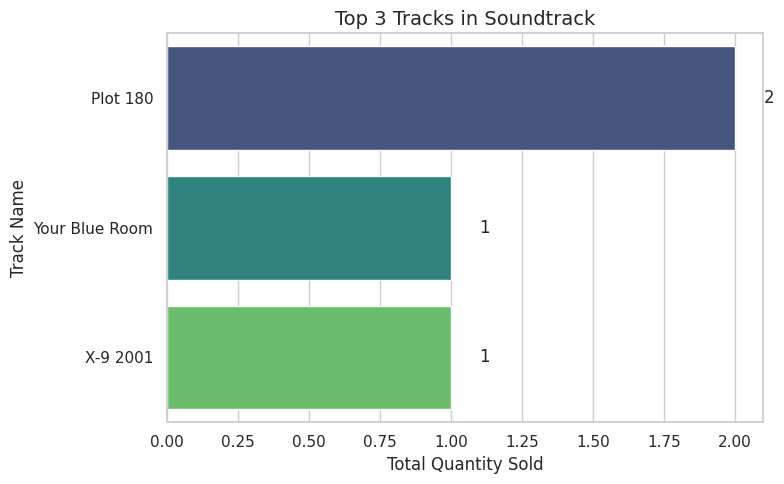

/tmp/ipython-input-335/3594036834.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


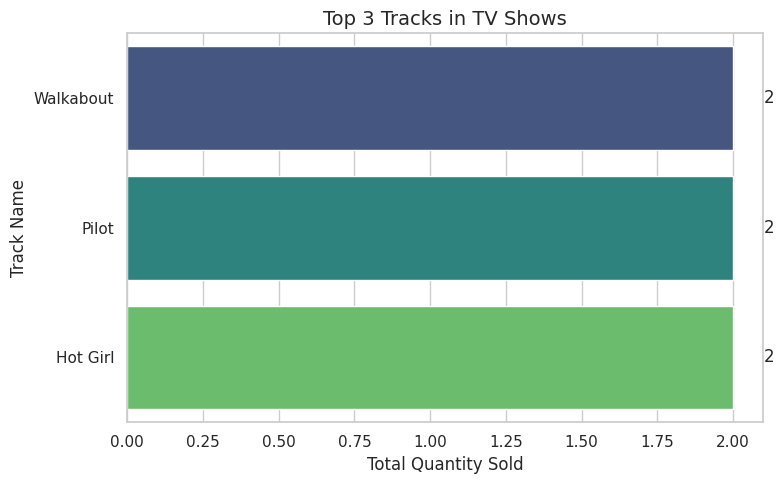

/tmp/ipython-input-335/3594036834.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


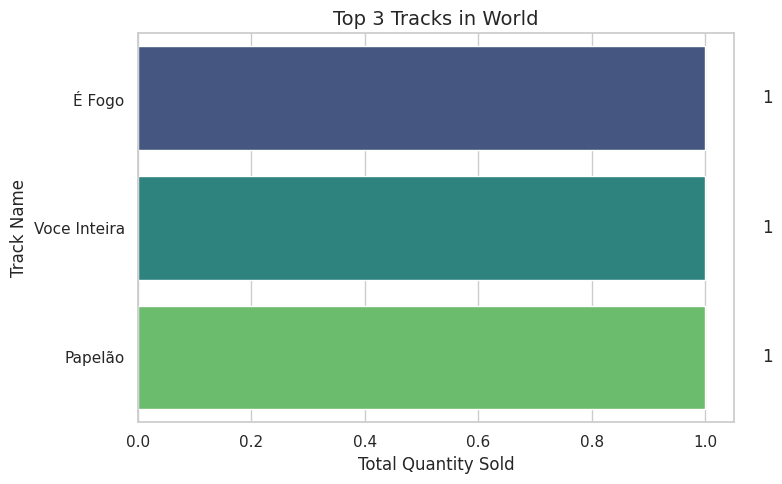

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use seaborn style
sns.set(style="whitegrid")

# Loop over each genre
for genre in top3_genre_named['GenreName'].unique():
    # Filter genre
    df_genre = top3_genre_named[top3_genre_named['GenreName'] == genre].copy()

    # Sort by Total_Quantity descending, pick top 3
    df_top3 = df_genre.sort_values(by='Total_Quantity', ascending=False).head(3)

    if df_top3.empty:
        continue  # skip empty genres

    plt.figure(figsize=(8, 5))
    ax = sns.barplot(
        x="Total_Quantity",
        y="Product",
        data=df_top3,
        palette="viridis"
    )

    # Add labels at end of bars
    for i, row in enumerate(df_top3.itertuples()):
        ax.text(row.Total_Quantity + 0.1, i, str(row.Total_Quantity), va='center')

    plt.title(f"Top 3 Tracks in {genre}", fontsize=14)
    plt.xlabel("Total Quantity Sold")
    plt.ylabel("Track Name")
    plt.tight_layout()
    plt.show()